In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import oracledb

print("pandas and oracledb ready")

pandas and oracledb ready


In [2]:
!pip install oracledb

In [3]:
conn = oracledb.connect(
    user="usr",
    password="pswd",
    dsn="localhost:1521/orcl",
    mode=oracledb.SYSDBA
)

print("Connected successfully")

Connected successfully


In [4]:
query = """
SELECT username
FROM dba_users
FETCH FIRST 10 ROWS ONLY
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\1709636006.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,USERNAME
0,SYS
1,SYSTEM
2,XS$NULL
3,OJVMSYS
4,LBACSYS
5,OUTLN
6,SYS$UMF
7,DBSNMP
8,APPQOSSYS
9,DBSFWUSER


In [5]:
query = """
SELECT transaction_amount
FROM bankTransactions
FETCH FIRST 10 ROWS ONLY
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\927978178.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,TRANSACTION_AMOUNT
0,2442.84
1,2051.46
2,374.82
3,718.60
4,4445.52
5,2427.13
6,1786.27
7,179.30
8,247.79
9,1917.72


## Monthly Transaction Analysis

This section analyzes monthly transaction activity by examining total transaction count and overall transaction amount. It helps identify transaction trends and periods with higher financial activity.

In [6]:
query = """
select 
  trunc(transaction_date, 'MM') as month,
  count(*) as transaction_count,
  sum(transaction_amount) as total_amount
from bankTransactions
group by trunc(transaction_date, 'MM')
order by month
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\3444649651.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,MONTH,TRANSACTION_COUNT,TOTAL_AMOUNT
0,2024-03-01,65,172878.45
1,2024-04-01,613,1459680.95
2,2024-05-01,670,1372220.68
3,2024-06-01,650,1300012.99
4,2024-07-01,676,1525689.96
5,2024-08-01,617,1352299.54
6,2024-09-01,588,1210350.88
7,2024-10-01,595,1341176.43
8,2024-11-01,603,1207372.40
9,2024-12-01,637,1253200.01


In [7]:
df['AVG_AMOUNT'] = df['TOTAL_AMOUNT'] / df['TRANSACTION_COUNT']

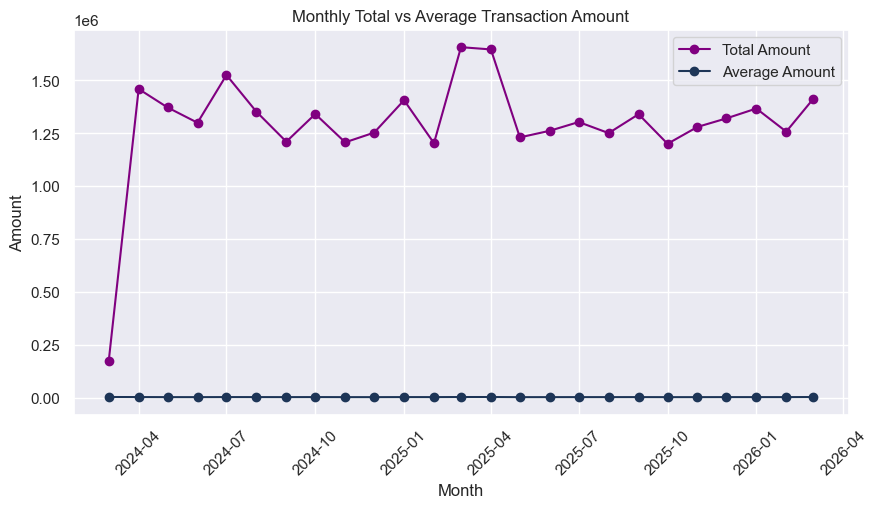

In [8]:
plt.figure(figsize=(10,5))

# Total amount
plt.plot(
    df['MONTH'], 
    df['TOTAL_AMOUNT'], 
    marker='o', 
    color='purple',
    label='Total Amount'
)

# Average amount
plt.plot(
    df['MONTH'], 
    df['AVG_AMOUNT'], 
    marker='o', 
    color='#1D3557',
    label='Average Amount'
)

plt.title("Monthly Total vs Average Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## Geographic Transactions Comparison

This analysis compares transaction behavior across different countries based on source and destination information. It highlights regional differences in average transaction amounts and transaction flow.

In [9]:
query1 = """
select source_country, trunc(avg(transaction_amount)) as average_amount
from bankTransactions
group by source_country
"""

df_source = pd.read_sql(query1, conn)


query2 = """ 
select destination_country, trunc(avg(transaction_amount)) as average_amount
from bankTransactions
group by destination_country
"""

df_dest = pd.read_sql(query2, conn)


C:\Users\irada\AppData\Local\Temp\ipykernel_10916\4215529683.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_source = pd.read_sql(query1, conn)
C:\Users\irada\AppData\Local\Temp\ipykernel_10916\4215529683.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dest = pd.read_sql(query2, conn)


In [10]:
df_merged = pd.merge(
    df_source,
    df_dest,
    left_on='SOURCE_COUNTRY',
    right_on='DESTINATION_COUNTRY',
    how='inner'
)

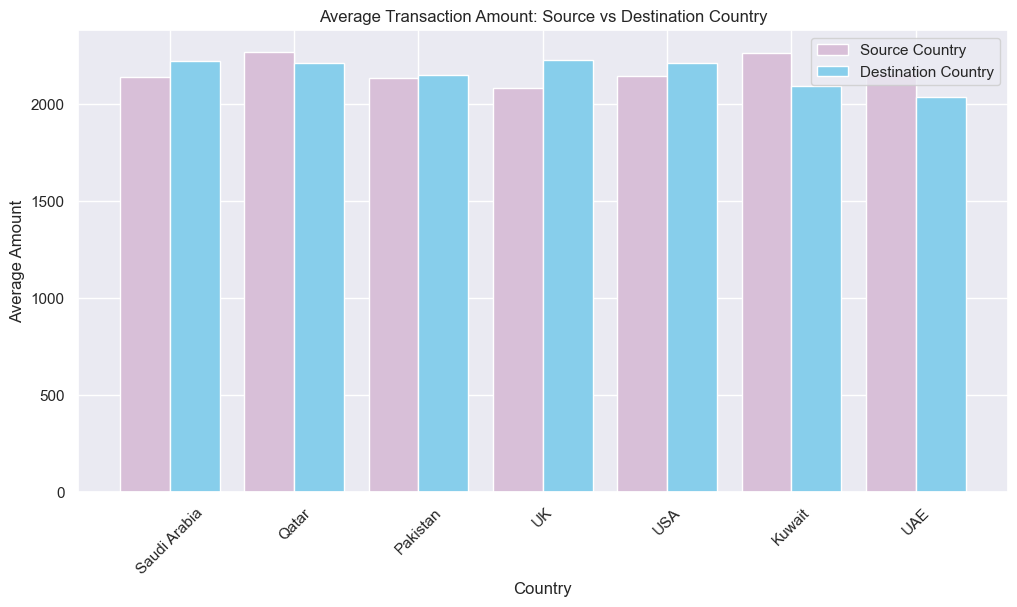

In [11]:
x = np.arange(len(df_merged))

plt.figure(figsize=(12,6))

plt.bar(
    x - 0.2,
    df_merged['AVERAGE_AMOUNT_x'],
    width=0.4,
    color = 'thistle',
    label='Source Country'
)

plt.bar(
    x + 0.2,
    df_merged['AVERAGE_AMOUNT_y'],
    width=0.4,
    color = 'skyblue',
    label='Destination Country'
)

plt.xticks(x, df_merged['SOURCE_COUNTRY'], rotation=45)

plt.title("Average Transaction Amount: Source vs Destination Country")
plt.xlabel("Country")
plt.ylabel("Average Amount")

plt.legend()
plt.show()

## Top Customers by Transaction Activity

This section identifies the customers with the highest number of transactions across countries. The analysis helps detect highly active users and customer transaction patterns.

In [12]:
query = """ 
select * from (select source_country,customer_id,transaction_count,
row_number() over(order by transaction_count desc) as rn
from (
select source_country,customer_id,count(transaction_id)as transaction_count
from bankTransactions group by source_country, customer_id
))
where rn <= 10
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\3252881415.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,SOURCE_COUNTRY,CUSTOMER_ID,TRANSACTION_COUNT,RN
0,Saudi Arabia,CUST8485,5,1
1,UAE,CUST6606,5,2
2,Saudi Arabia,CUST3334,5,3
3,UAE,CUST8113,5,4
4,Saudi Arabia,CUST7406,5,5
5,UAE,CUST4525,4,6
6,Saudi Arabia,CUST2014,4,7
7,Saudi Arabia,CUST7385,4,8
8,Saudi Arabia,CUST6736,4,9
9,Saudi Arabia,CUST4302,4,10


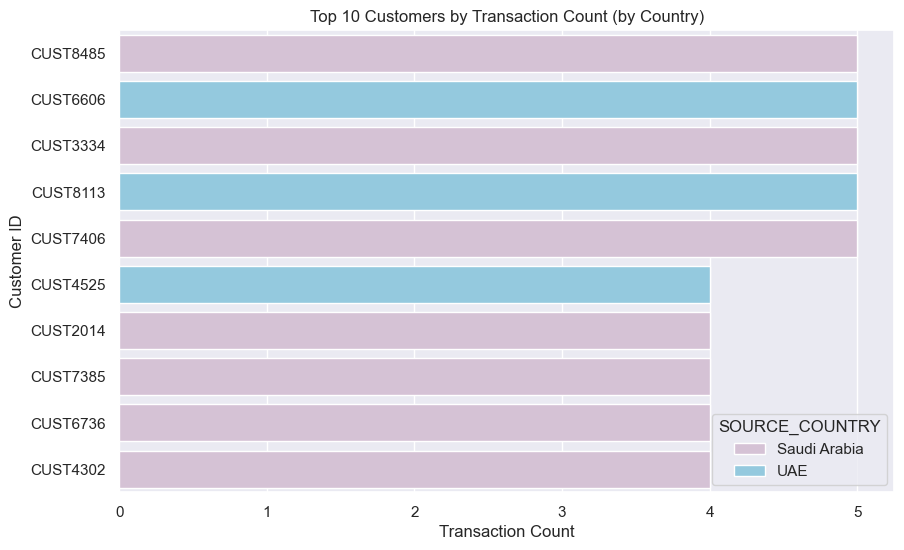

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='TRANSACTION_COUNT',
    y='CUSTOMER_ID',
    hue='SOURCE_COUNTRY',
    palette=['thistle', 'skyblue']
)

plt.title("Top 10 Customers by Transaction Count (by Country)")
plt.xlabel("Transaction Count")
plt.ylabel("Customer ID")

plt.show()

## Exchange Rate Impact on Converted Amounts

This analysis examines how different exchange rate levels affect converted transaction amounts. It provides insight into currency conversion behavior and financial value changes.

In [14]:
query = """ 
select round(avg(converted_amount),2) as avg_converted,
case 
    when exchange_rate < 100 then 'low'
    when exchange_rate between 100 and 500 then 'medium'
    else 'high'
end as rate_level
  
from banktransactions
group by 
case 
    when exchange_rate < 100 then 'low'
    when exchange_rate between 100 and 500 then 'medium'
    else 'high'
end
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\2347714374.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,AVG_CONVERTED,RATE_LEVEL
0,147751.11,low
1,2074559.29,high
2,446697.20,medium


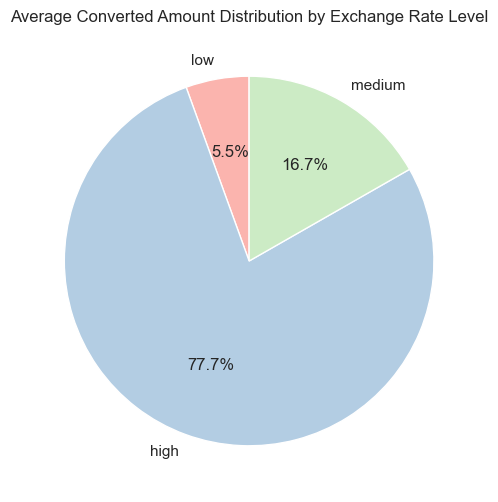

In [15]:
plt.figure(figsize=(6,6))

plt.pie(
    df['AVG_CONVERTED'],
    labels=df['RATE_LEVEL'],
    autopct='%1.1f%%',
    colors = plt.get_cmap('Pastel1').colors,
    startangle=90
)

plt.title("Average Converted Amount Distribution by Exchange Rate Level")

plt.show()

## Device Type and Processing Performance Analysis

This section compares transaction volume and average processing time across different device types. It helps evaluate system performance and user transaction behavior by device.

In [16]:
query = """
select device_type, count(transaction_id) as transaction_cout,
trunc(avg(processing_time_seconds)) as average_processing_time
from bankTransactions
group by device_type 
order by  count(transaction_id) desc
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\1424639084.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,DEVICE_TYPE,TRANSACTION_COUT,AVERAGE_PROCESSING_TIME
0,ATM,5060,63
1,Mobile,5029,62
2,Desktop,4911,62


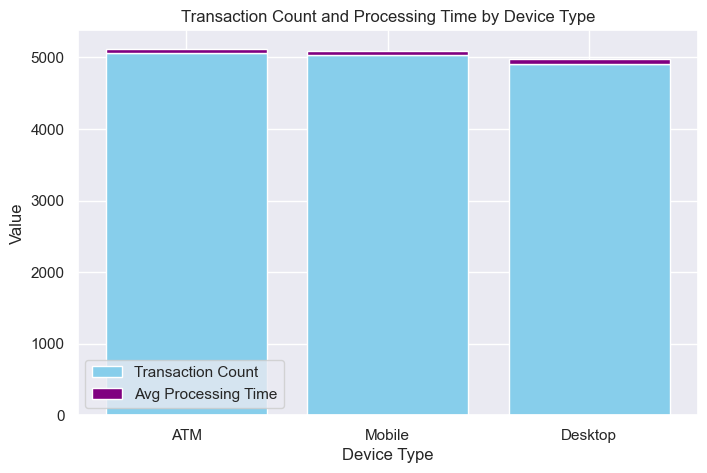

In [17]:
# stacked barchart
plt.figure(figsize=(8,5))

plt.bar(
    df['DEVICE_TYPE'],
    df['TRANSACTION_COUT'],
    color='skyblue',
    label='Transaction Count'
)

plt.bar(
    df['DEVICE_TYPE'],
    df['AVERAGE_PROCESSING_TIME'],
    bottom=df['TRANSACTION_COUT'],
    color='purple',
    label='Avg Processing Time'
)

plt.title("Transaction Count and Processing Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Value")

plt.legend()
plt.show()

## Monthly Transaction Trend Analysis

This analysis examines monthly transaction behavior by comparing cumulative growth, maximum, minimum, and average transaction amounts over time.

In [18]:
query = """
select 
    trunc(transaction_date, 'MM') as month,
    sum(transaction_amount) as total_amount,
    max(transaction_amount) as max_amount,
    min(transaction_amount) as min_amount,
    round(avg(transaction_amount), 2) as avg_amount
from bankTransactions
group by trunc(transaction_date, 'MM')
order by month
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\819740154.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,MONTH,TOTAL_AMOUNT,MAX_AMOUNT,MIN_AMOUNT,AVG_AMOUNT
0,2024-03-01,172878.45,12899.71,158.52,2659.67
1,2024-04-01,1459680.95,17601.67,126.82,2381.21
2,2024-05-01,1372220.68,14192.21,100.68,2048.09
3,2024-06-01,1300012.99,12870.43,105.50,2000.02
4,2024-07-01,1525689.96,16745.67,100.29,2256.94
5,2024-08-01,1352299.54,15483.44,100.03,2191.73
6,2024-09-01,1210350.88,10102.84,102.05,2058.42
7,2024-10-01,1341176.43,15178.74,101.86,2254.08
8,2024-11-01,1207372.40,14701.42,102.03,2002.28
9,2024-12-01,1253200.01,12465.28,105.24,1967.35


In [19]:
df['MONTH'] = pd.to_datetime(df['MONTH'])

In [20]:
df['CUMULATIVE_AMOUNT'] = df['TOTAL_AMOUNT'].cumsum()

In [21]:
df['CUMULATIVE_AMOUNT'] = df['TOTAL_AMOUNT'].cumsum()

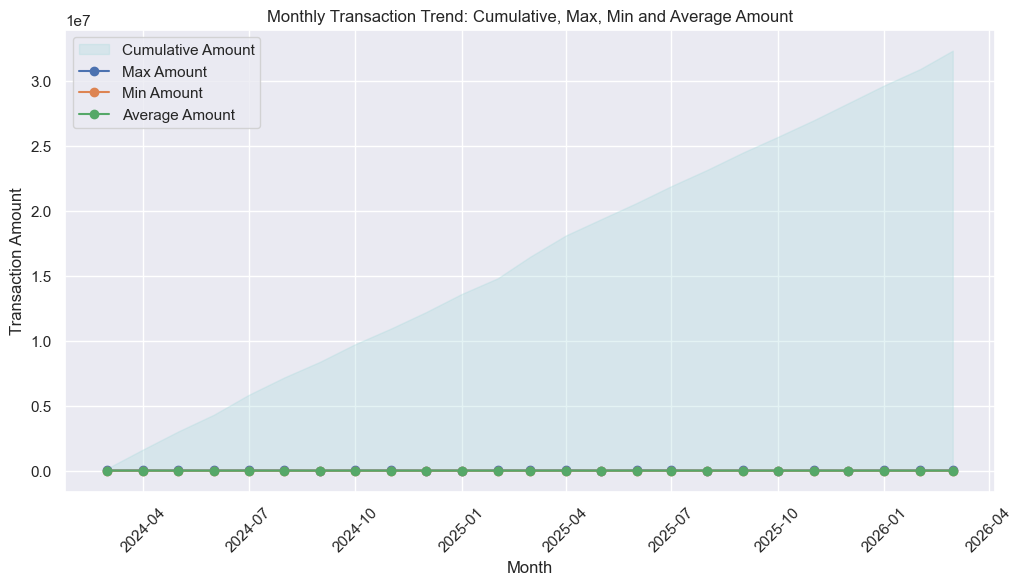

In [22]:
plt.figure(figsize=(12,6))

# Area chart - cumulative amount
plt.fill_between(
    df['MONTH'],
    df['CUMULATIVE_AMOUNT'],
    alpha=0.3,
    color='#A8DADC',
    label='Cumulative Amount'
)

# Line charts
plt.plot(df['MONTH'], df['MAX_AMOUNT'], marker='o', label='Max Amount')
plt.plot(df['MONTH'], df['MIN_AMOUNT'], marker='o', label='Min Amount')
plt.plot(df['MONTH'], df['AVG_AMOUNT'], marker='o', label='Average Amount')

plt.title("Monthly Transaction Trend: Cumulative, Max, Min and Average Amount")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## Customer Segmentation by Spending Quartiles

Customers are divided into four groups based on total spending

In [23]:
query = """
select customer_id,total_amount,
ntile(4) over(order by total_amount desc) as quartile
from(select customer_id, sum(transaction_amount) as total_amount from bankTransactions
group by customer_id)
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\1437174895.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,CUSTOMER_ID,TOTAL_AMOUNT,QUARTILE
0,CUST8485,27563.63,1
1,CUST7082,25918.96,1
2,CUST4965,24673.03,1
3,CUST2509,24570.82,1
4,CUST7117,24070.80,1
...,...,...,...
7255,CUST4788,102.39,4
7256,CUST2499,102.27,4
7257,CUST1235,102.21,4
7258,CUST3556,102.05,4


In [24]:
quartile_counts = df['QUARTILE'].value_counts().sort_index()
quartile_counts

QUARTILE
1    1815
2    1815
3    1815
4    1815
Name: count, dtype: int64

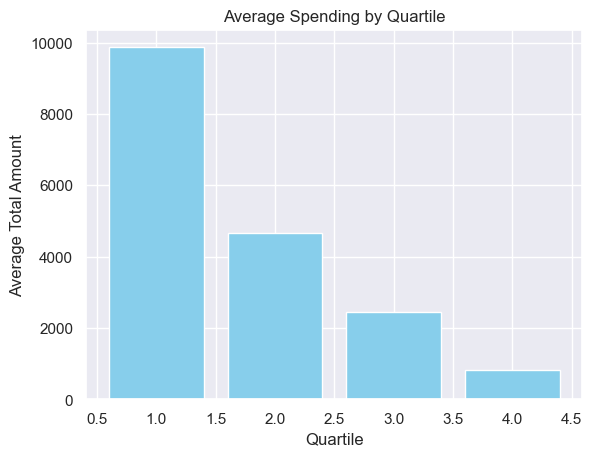

In [25]:
avg_spending = df.groupby('QUARTILE')['TOTAL_AMOUNT'].mean()

plt.bar(avg_spending.index, avg_spending.values,  color='skyblue')

plt.title("Average Spending by Quartile")
plt.xlabel("Quartile")
plt.ylabel("Average Total Amount")

plt.show()

## Fraud vs Non-Fraud Transaction Amount Analysis

This section compares fraudulent and non-fraudulent transactions based on transaction amounts and patterns. The analysis helps detect abnormal financial behavior and potential fraud risks.

In [26]:
query = """
select 
transaction_amount
from bankTransactions
where fraud_flag = 1
"""

df= pd.read_sql(query, conn)


C:\Users\irada\AppData\Local\Temp\ipykernel_10916\4216081248.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df= pd.read_sql(query, conn)


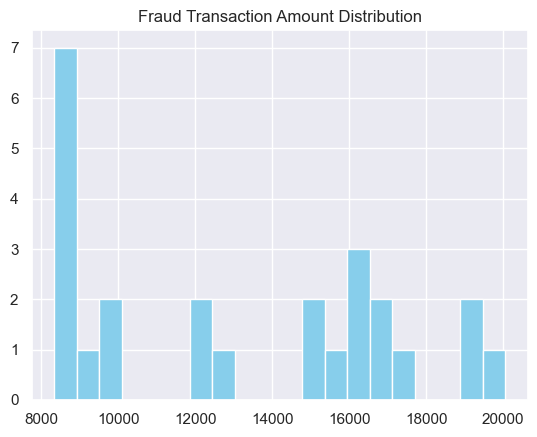

In [27]:
plt.hist(df['TRANSACTION_AMOUNT'], bins=20,  color='skyblue')
plt.title("Fraud Transaction Amount Distribution")
plt.show()

In [28]:
query = """
select fraud_flag, transaction_amount
from bankTransactions
"""

df_scatter = pd.read_sql(query, conn)


C:\Users\irada\AppData\Local\Temp\ipykernel_10916\140041036.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_scatter = pd.read_sql(query, conn)


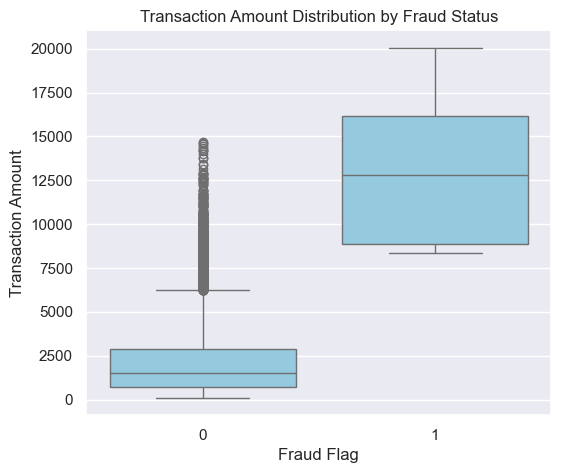

In [29]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_scatter,
    x='FRAUD_FLAG',
    y='TRANSACTION_AMOUNT',
     color='skyblue'
)

plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Fraud Flag")
plt.ylabel("Transaction Amount")

plt.show()

In [30]:
query = """
select transaction_amount, converted_amount, fee_charged, tax_applied, risk_score
from bankTransactions
"""

df_heat = pd.read_sql(query, conn)

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\3505139200.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_heat = pd.read_sql(query, conn)


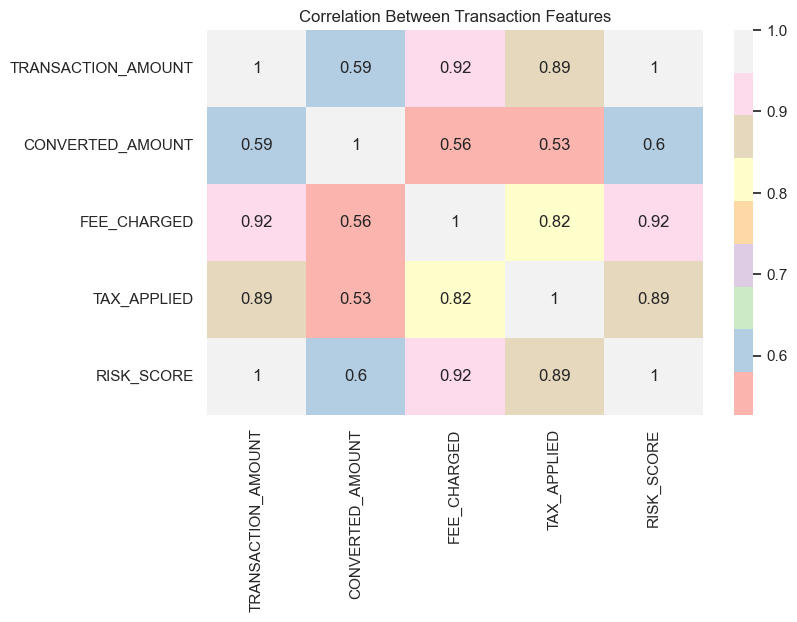

In [31]:
plt.figure(figsize=(8,5))

sns.heatmap(df_heat.corr(), annot=True, cmap='Pastel1')

plt.title("Correlation Between Transaction Features")

plt.show()

## Risk Segmentation of Transactions

This analysis categorizes transactions into different risk levels and examines their distribution. It provides insight into the proportion of low, medium, and high-risk transactions.

In [32]:
query = """ 
select avg(risk_score), max(risk_score), min(risk_score) from bankTransactions
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\2513805961.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,AVG(RISK_SCORE),MAX(RISK_SCORE),MIN(RISK_SCORE)
0,10.3136,100,0


In [33]:
query = """ 
select count(*) as count_of_risk_transactions,
case 
    when risk_score < 10 then 'Low'
    when risk_score between 10 and 50 then 'Medium'
    else 'High'
end as risk_level

from bankTransactions
group by 
case 
    when risk_score < 10 then 'Low'
    when risk_score between 10 and 50 then 'Medium'
    else 'High'
end
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\1012090545.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,COUNT_OF_RISK_TRANSACTIONS,RISK_LEVEL
0,9035,Low
1,117,High
2,5848,Medium


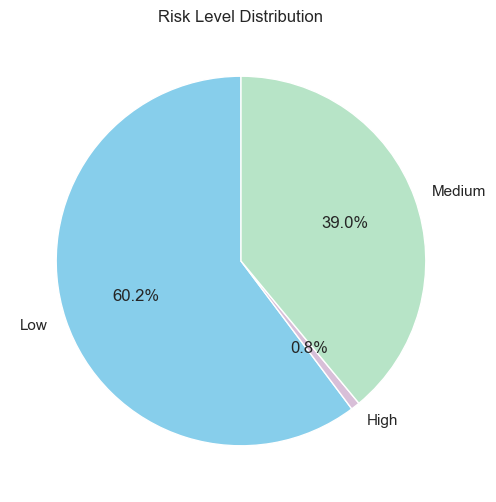

In [34]:
# colors
plt.figure(figsize=(10,6))

colors = ['skyblue', 'thistle', '#B7E4C7']

plt.pie(
    df['COUNT_OF_RISK_TRANSACTIONS'],
    labels=df['RISK_LEVEL'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Risk Level Distribution")
plt.show()

## Largest Transaction Share per Customer

This section measures how much a customer’s largest transaction contributes to their total transaction amount. It helps identify customers whose spending is concentrated in a single large transaction.

In [35]:
query = """
select customer_id, total_amount, max_tr_amount,
round((max_tr_amount /total_amount)*100, 2) as max_tr_percentage
from(
select customer_id, sum(transaction_amount) as total_amount,
max(transaction_amount) as max_tr_amount
from bankTransactions
group by customer_id)
order by max_tr_percentage desc
"""

df = pd.read_sql(query, conn)
df

C:\Users\irada\AppData\Local\Temp\ipykernel_10916\638851011.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,CUSTOMER_ID,TOTAL_AMOUNT,MAX_TR_AMOUNT,MAX_TR_PERCENTAGE
0,CUST9770,2341.12,2341.12,100.00
1,CUST9411,4341.00,4341.00,100.00
2,CUST9015,2844.26,2844.26,100.00
3,CUST3375,948.55,948.55,100.00
4,CUST8521,2552.56,2552.56,100.00
...,...,...,...,...
7255,CUST8000,5220.07,1286.60,24.65
7256,CUST2934,7329.40,1800.50,24.57
7257,CUST2372,14812.93,3412.92,23.04
7258,CUST8485,27563.63,5796.19,21.03


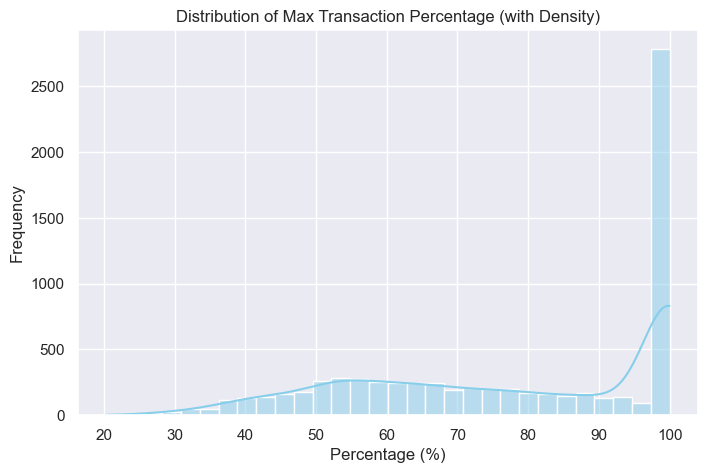

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['MAX_TR_PERCENTAGE'],
    bins=30,
    color = 'skyblue',
    kde=True 
)

plt.title("Distribution of Max Transaction Percentage (with Density)")
plt.xlabel("Percentage (%)")
plt.ylabel("Frequency")

plt.show()

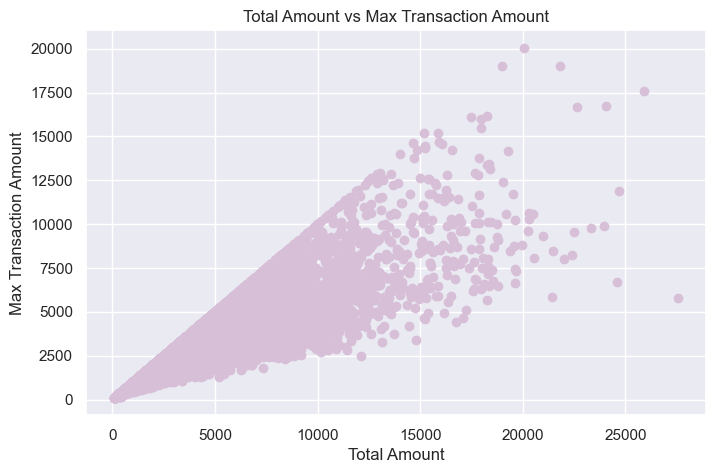

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(df['TOTAL_AMOUNT'], df['MAX_TR_AMOUNT'], color = 'thistle')

plt.title("Total Amount vs Max Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Max Transaction Amount")

plt.show()